# 4 · Reward Reliability  `[TRAINING ↔ EVAL]`

Is the **short partial-conversation training reward** a faithful proxy for the **full-conversation eval**? The training reward scores a conversation mid-stream (after `MIN_CONV_LENGTH`=12 turns, optionally +K look-ahead); the thesis evaluates the *finished* conversation. This notebook tests how well the two agree, and whether look-ahead helps. For a reader questioning the reward design.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath("."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, pref, figures, plots
S = exp3.notebook_setup()

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 6), ('GRPO_LA0', 6), ('GRPO_LA5', 2)]
scores_long: (16128, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> C:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


## 1 · Rank agreement vs conversation length  `[TRAINING ↔ EVAL]`
**Purpose.** Rebuild the Exp2 partial-conv statistic on Exp3 data (from the per-branch `prefix` in `generations.jsonl`, no new oracle calls): for each scored length `n_turns`, the fraction of conversation pairs whose proxy-score ordering matches the full-conv eval ordering. **Read:** 0.5 = chance; higher = more faithful. Comparing **LA0 vs LA5** tests whether look-ahead buys faithfulness. Note MCL=12 means the shortest training cut is already 12 turns (Exp2 was unreliable below ~10).

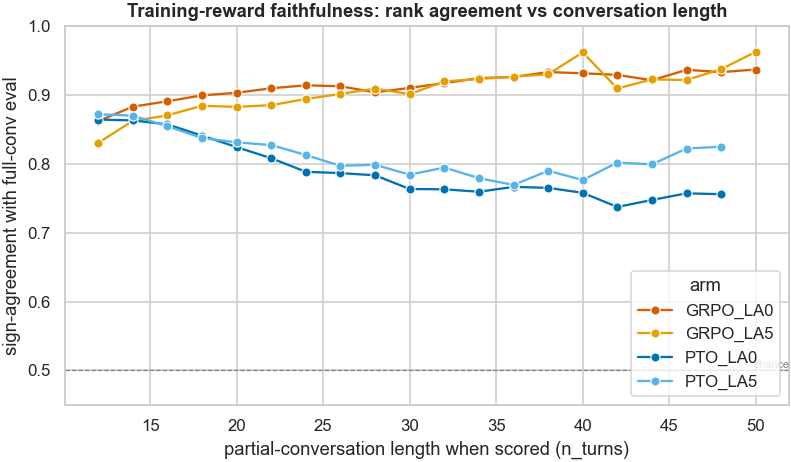

arm,GRPO_LA0,GRPO_LA5,PTO_LA0,PTO_LA5
n_turns,,,,
12,0.862,0.831,0.865,0.872
14,0.883,0.863,0.863,0.870
16,0.891,0.871,0.858,0.855
18,0.900,0.885,0.841,0.838
20,0.904,0.883,0.825,0.832
22,0.910,0.886,0.808,0.828
24,0.914,0.895,0.789,0.813
26,0.913,0.902,0.787,0.797
28,0.904,0.910,0.784,0.799


In [2]:
BR = training.load_branch_reliability(S.ARMS)
RA = stats.rank_agreement_by_nturns(BR, S.SCORES, metric="Q1Q2")
fig = plots.reliability_curve(RA, palette=S.PALETTE)
if fig: exp3.save_fig(fig, "reward_reliability_curve", caption="Sign-agreement between the partial-conv training reward and the full-conv eval (Q1+Q2) vs the length at which the conversation was scored; per arm. 0.5 = chance. LA0 vs LA5 tests whether look-ahead improves faithfulness."); plt.show()
if not RA.empty:
    display(RA.pivot_table(index="n_turns", columns="arm", values="agreement").round(3))

## 2 · Proxy reward vs full-conv eval, per iteration  `[TRAINING ↔ EVAL]`
**Purpose.** The aggregate view: mean training proxy reward vs mean full-conv eval per (arm, iteration), dashed y=x. **Read:** points below the line = the proxy over-rates the policy (promising openings that don't pay off by session end).

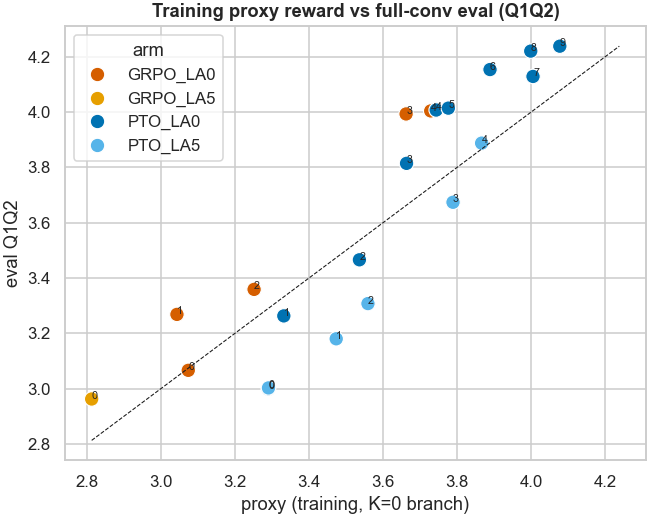

In [3]:
GENS = training.load_generations(S.ARMS)
fig = plots.faithfulness_proxy_vs_eval(S.SCORES, GENS)
if fig: exp3.save_fig(fig, "faithfulness_proxy_vs_eval", caption="Per (arm, iteration): mean training proxy reward (oracle on the partial branch) vs full-conversation eval Q1+Q2; dashed y=x."); plt.show()

## 3 · PTO preference decisiveness by branch depth  `[TRAINING]`
**Purpose.** Within PTO, how the chosen-rejected score `margin` varies with `branch_depth` (deeper = later in the trunk = longer prefix). **Read:** a margin that grows with depth = the oracle discriminates more confidently on longer context. (PTO-only — GRPO has no pairs.)

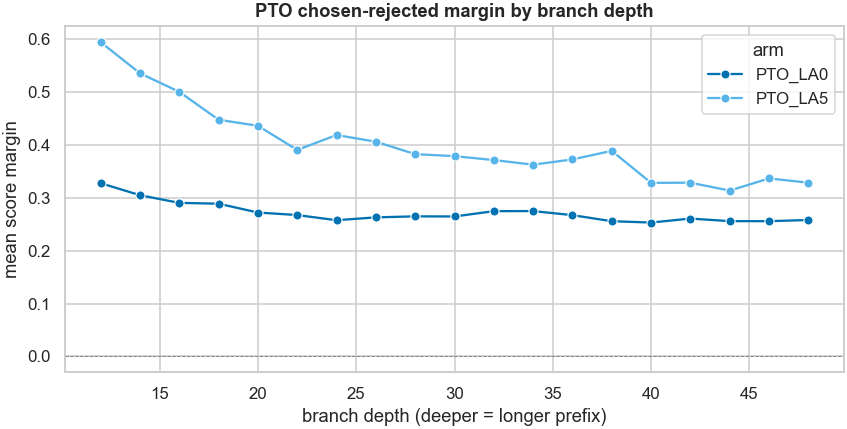

In [4]:
PP = training.load_pref_pairs([a for a in S.ARMS if a.method == "PTO"])
if not PP.empty and "branch_depth" in PP.columns:
    g = PP.groupby(["arm", "branch_depth"])["margin"].mean().reset_index()
    fig, ax = plt.subplots(figsize=(8, 4.2))
    sns.lineplot(g, x="branch_depth", y="margin", hue="arm", marker="o", palette=figures.arm_palette(sorted(g.arm.unique())), ax=ax)
    ax.axhline(0, color="grey", lw=0.6, ls="--"); ax.set_title("PTO chosen-rejected margin by branch depth")
    ax.set_xlabel("branch depth (deeper = longer prefix)"); ax.set_ylabel("mean score margin"); fig.tight_layout(); plt.show()
else:
    print("No PTO preference pairs available.")

## 4 · How to read this notebook
- The **reliability curve (§1)** is the headline: it quantifies how much the training reward can be trusted at the length it actually scores. MCL=12 was chosen to stay out of the unreliable short-cut regime; the residual slope shows there is still signal to gain from longer context / look-ahead.
- **LA0 vs LA5:** if LA5 sits above LA0, look-ahead is making the short reward more faithful — the original motivation for the K knob.
- _(The motivation for MCL is the Exp2 `Partial_Conv_Oracle_EDA`, archived in `eda/archive_exp2/`, which showed agreement as low as 0.66 at n_turns=2.)_